In [78]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from scipy.stats import friedmanchisquare, pearsonr
from itertools import combinations

plt.rcParams['font.sans-serif'] = "Menlo"
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams.update({'font.size': 22})

#### Global Test

We run a global Friedman test to determine whether the differences between fingerprints are statistically significant (p-value < 0.05)

AUC

In [112]:
mean_aucs = pd.read_csv('combined_sets/auc_mean.csv')
ranked_aucs = mean_aucs.rank(axis=1, ascending=False)
                        
stat, p = friedmanchisquare(*ranked_aucs.values.T)
print('Q=%.3f, p=%.3f' % (stat, p))

Q=590.845, p=0.000


EF1

In [113]:
mean_ef1 = pd.read_csv('combined_sets/ef1_mean.csv')
ranked_ef1 = mean_ef1.rank(axis=1, ascending=False)

stat, p = friedmanchisquare(*ranked_ef1.values.T)
print('Q=%.3f, p=%.3f' % (stat, p))

Q=420.384, p=0.000


EF5

In [114]:
mean_ef5 = pd.read_csv('combined_sets/ef5_mean.csv')
ranked_ef5 = mean_ef5.rank(axis=1, ascending=False)

stat, p = friedmanchisquare(*ranked_ef5.values.T)
print('Q=%.3f, p=%.3f' % (stat, p))

Q=527.625, p=0.000


BEDROC20

In [115]:
mean_bedroc20 = pd.read_csv('combined_sets/bedroc20_mean.csv')
ranked_bedroc20 = mean_bedroc20.rank(axis=1, ascending=False)

stat, p = friedmanchisquare(*ranked_bedroc20.values.T)
print('Q=%.3f, p=%.3f' % (stat, p))

Q=534.985, p=0.000


BEDROC100

In [116]:
mean_bedroc100 = pd.read_csv('combined_sets/bedroc100_mean.csv')
ranked_bedroc100 = mean_bedroc100.rank(axis=1, ascending=False)

stat, p = friedmanchisquare(*ranked_bedroc100.values.T)
print('Q=%.3f, p=%.3f' % (stat, p))

Q=471.008, p=0.000


RIE20

In [117]:
mean_rie20 = pd.read_csv('combined_sets/rie20_mean.csv')
ranked_rie20 = mean_rie20.rank(axis=1, ascending=False)

stat, p = friedmanchisquare(*ranked_rie20.values.T)
print('Q=%.3f, p=%.3f' % (stat, p))

Q=534.985, p=0.000


RIE100

In [118]:
mean_rie100 = pd.read_csv('combined_sets/rie100_mean.csv')
ranked_rie100 = mean_rie100.rank(axis=1, ascending=False)

stat, p = friedmanchisquare(*ranked_rie100.values.T)
print('Q=%.3f, p=%.3f' % (stat, p))

Q=471.008, p=0.000


#### Pairwise Test

We additionally run a pairwise Friedman test to determine which fingerprints are statistically significantly different from each other (p-value < 0.05)

In [119]:
import scikit_posthocs as sp
data = ranked_aucs.values

Riniker & Landrum

In [120]:
def generate_friedman_heatmaps(df, metric='auc'):

    # Separate the data into small molecules and peptides
    data = df.values
    data_small, data_peptides = data[:-60], data[-60:]

    # Perform the pairwise Friedman-Nemenyi test
    friedman_small, friedman_peptides = sp.posthoc_nemenyi_friedman(data_small), sp.posthoc_nemenyi_friedman(data_peptides)

    # Replace the values with 0 if the p-value is greater than 0.05 and 1 otherwise
    friedman_small = np.where(friedman_small > 0.05, 0, 1)
    friedman_peptides = np.where(friedman_peptides > 0.05, 0, 1)

    # Define IBM colorblind colormap
    ibm_colorblind = LinearSegmentedColormap.from_list('ibm_colorblind', ['#DC267F', '#648FFF'], N=256)

    # Plot heatmaps 
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))

    im = ax[0].imshow(friedman_small, cmap=ibm_colorblind)
    ax[0].set_title('ChEMBL, DUD, MUV')
    ax[0].set_xticks(np.arange(len(df.columns)))
    ax[0].set_yticks(np.arange(len(df.columns)))
    ax[0].set_xticklabels(df.columns)
    ax[0].set_yticklabels(df.columns)

    im = ax[1].imshow(friedman_peptides, cmap=ibm_colorblind)
    ax[1].set_title('Peptides')
    ax[1].set_xticks(np.arange(len(df.columns)))
    ax[1].set_yticks(np.arange(len(df.columns)))
    ax[1].set_xticklabels(df.columns)
    ax[1].set_yticklabels(df.columns)

    plt.setp(ax[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.setp(ax[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add frame to heatmap cells
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', lw=1)
            ax[0].add_patch(rect)
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', lw=1)
            ax[1].add_patch(rect)

    # Save figure 
    savename = f'plots/friedman_heatmaps_{metric}.png'
    plt.savefig(savename, dpi=1200, bbox_inches='tight')

Generate figures

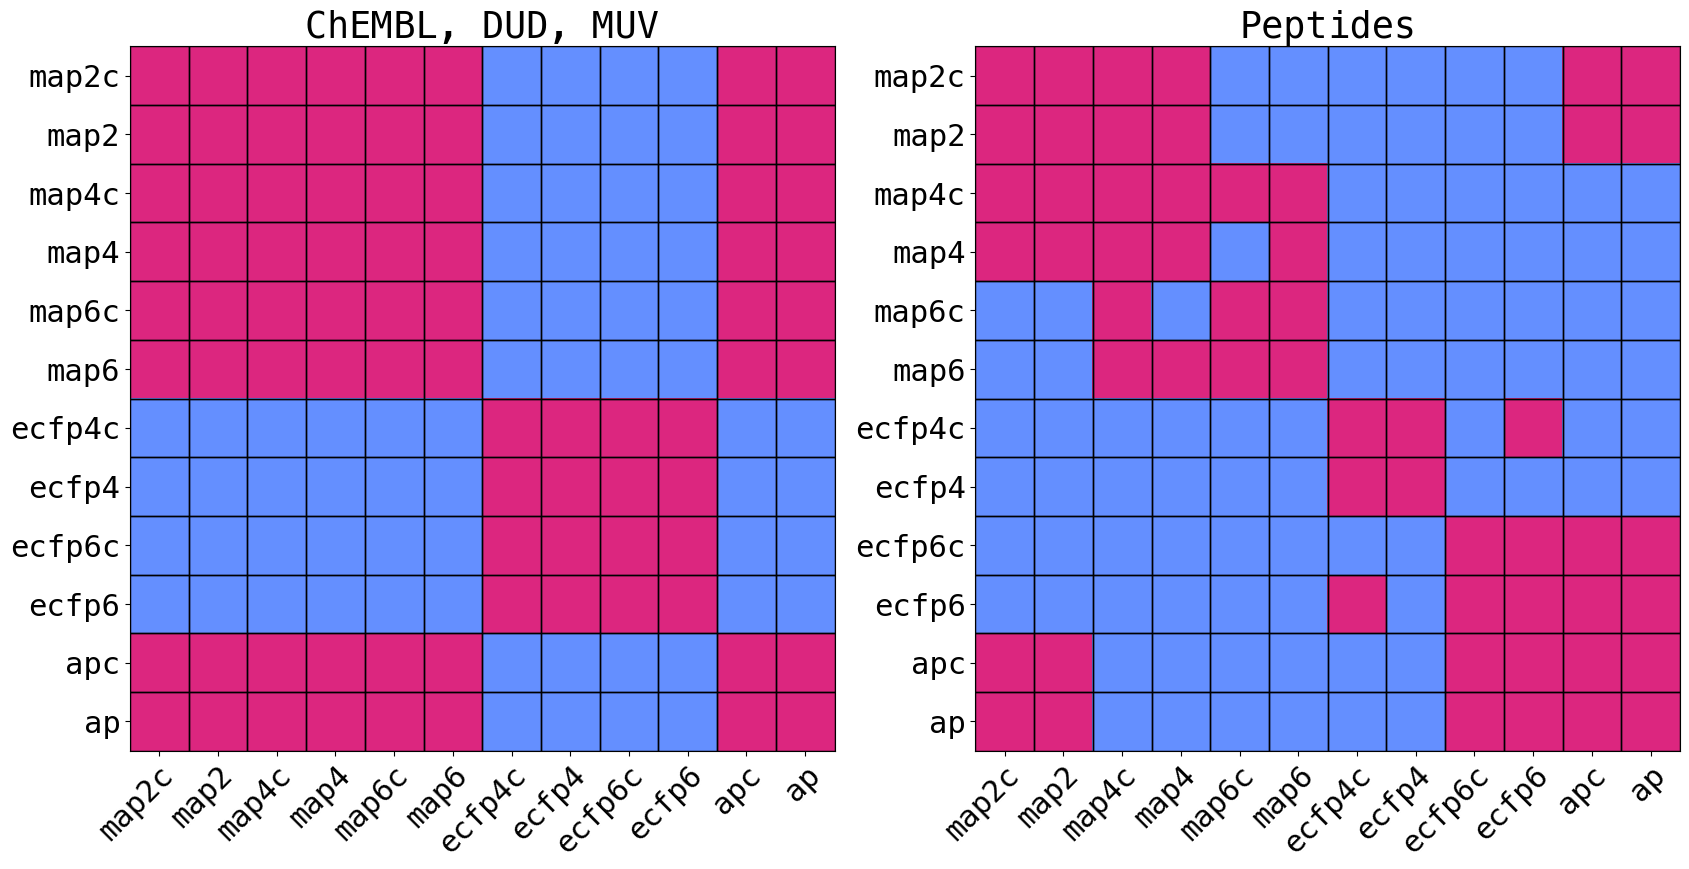

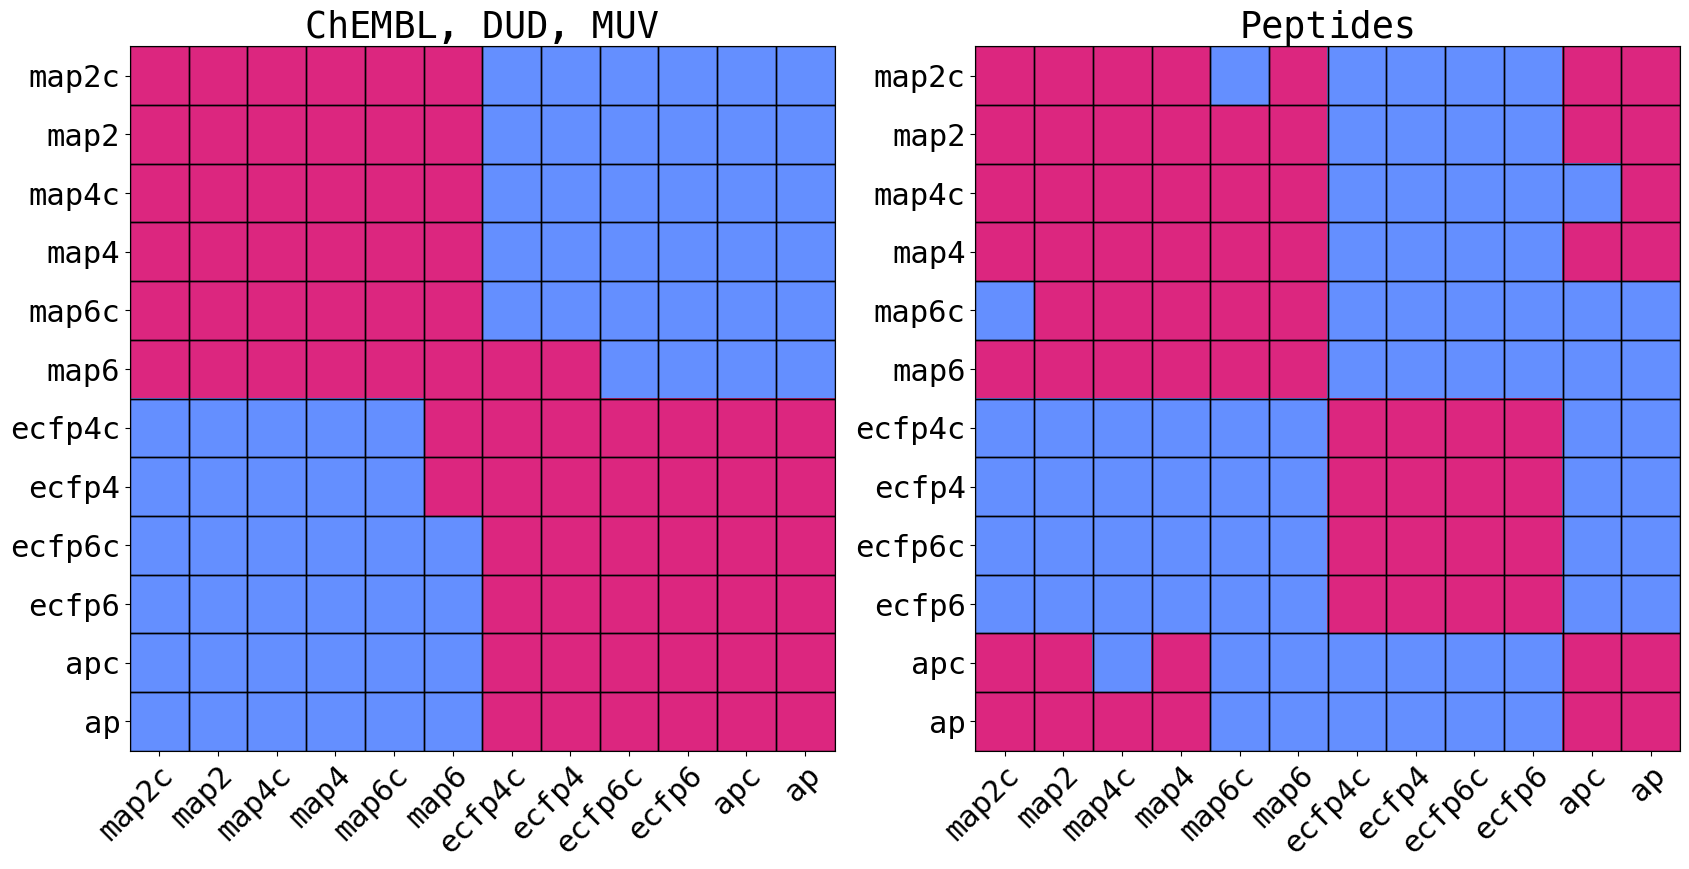

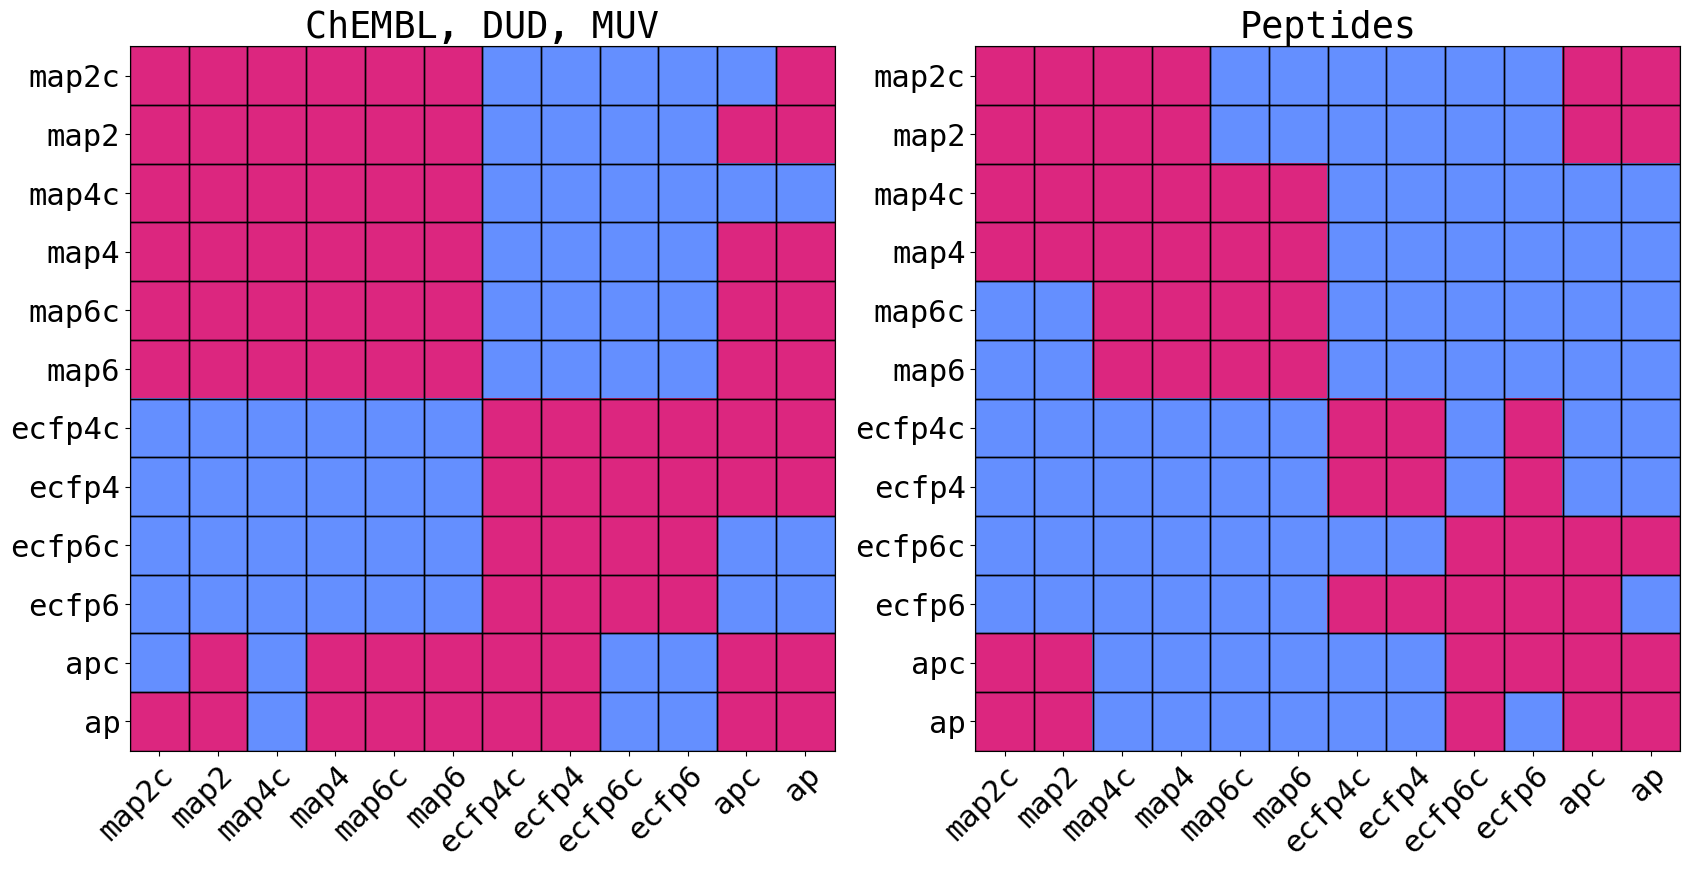

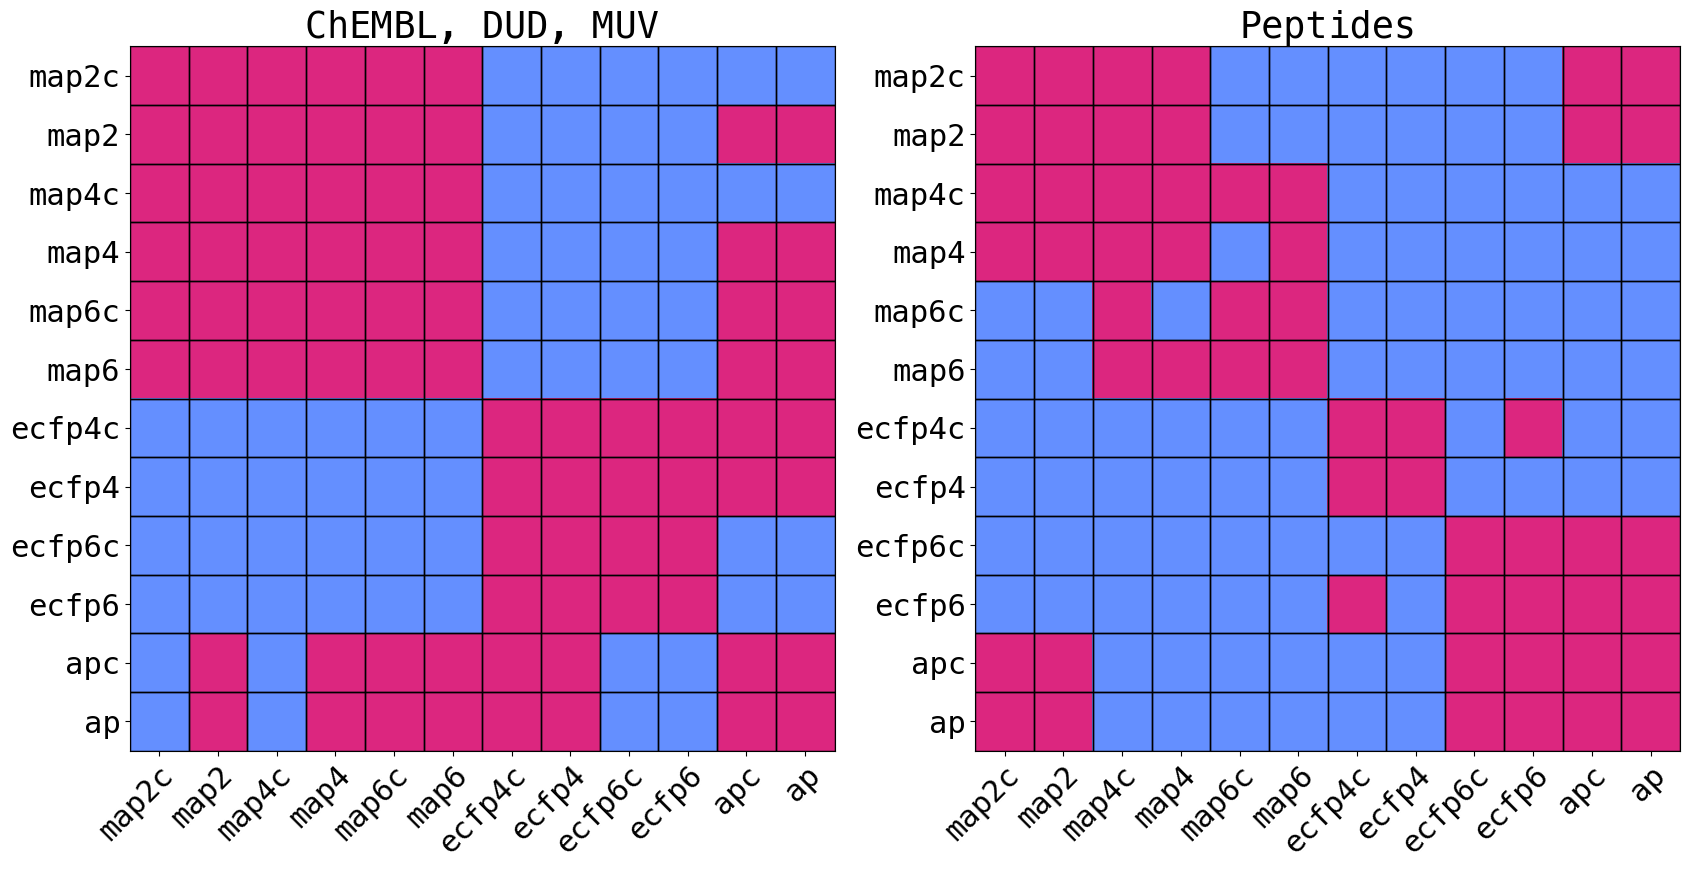

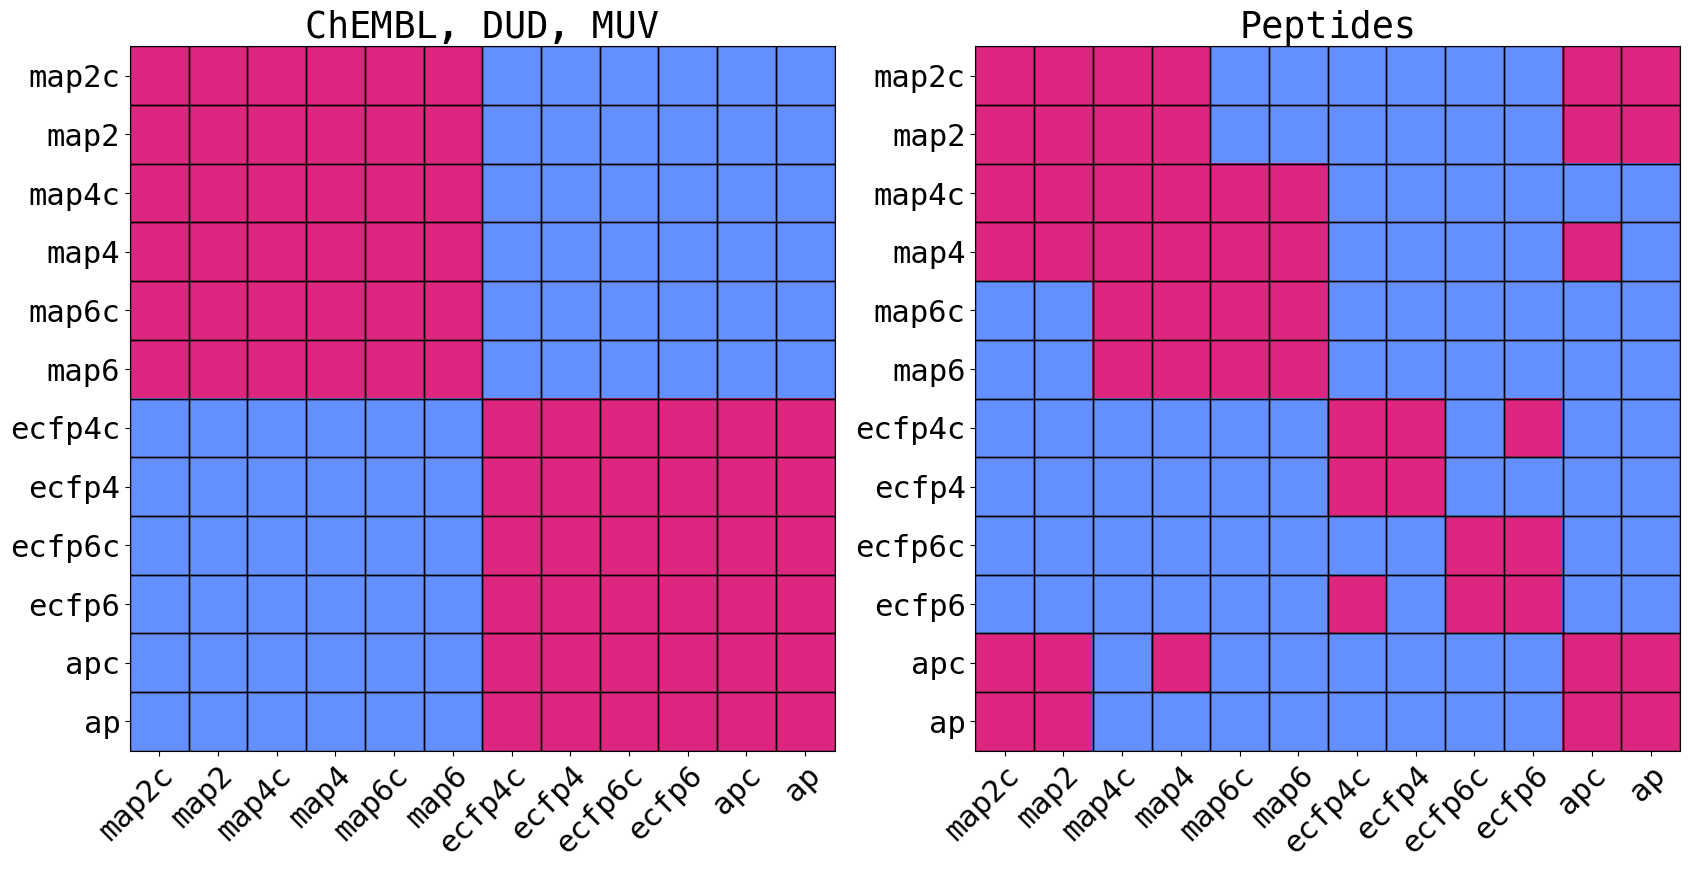

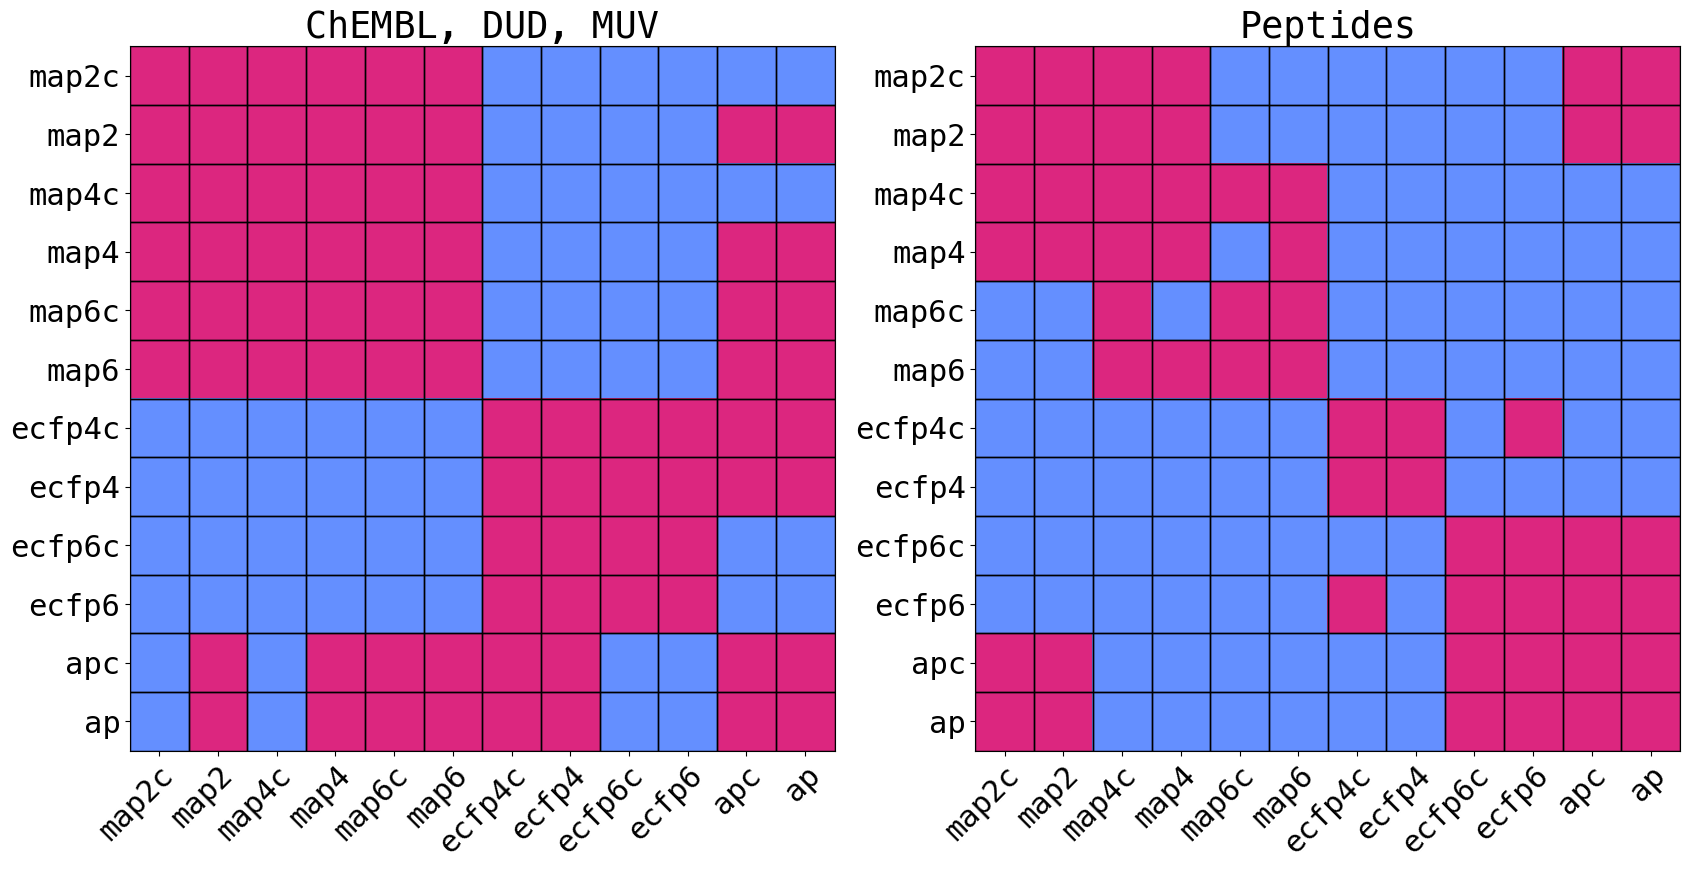

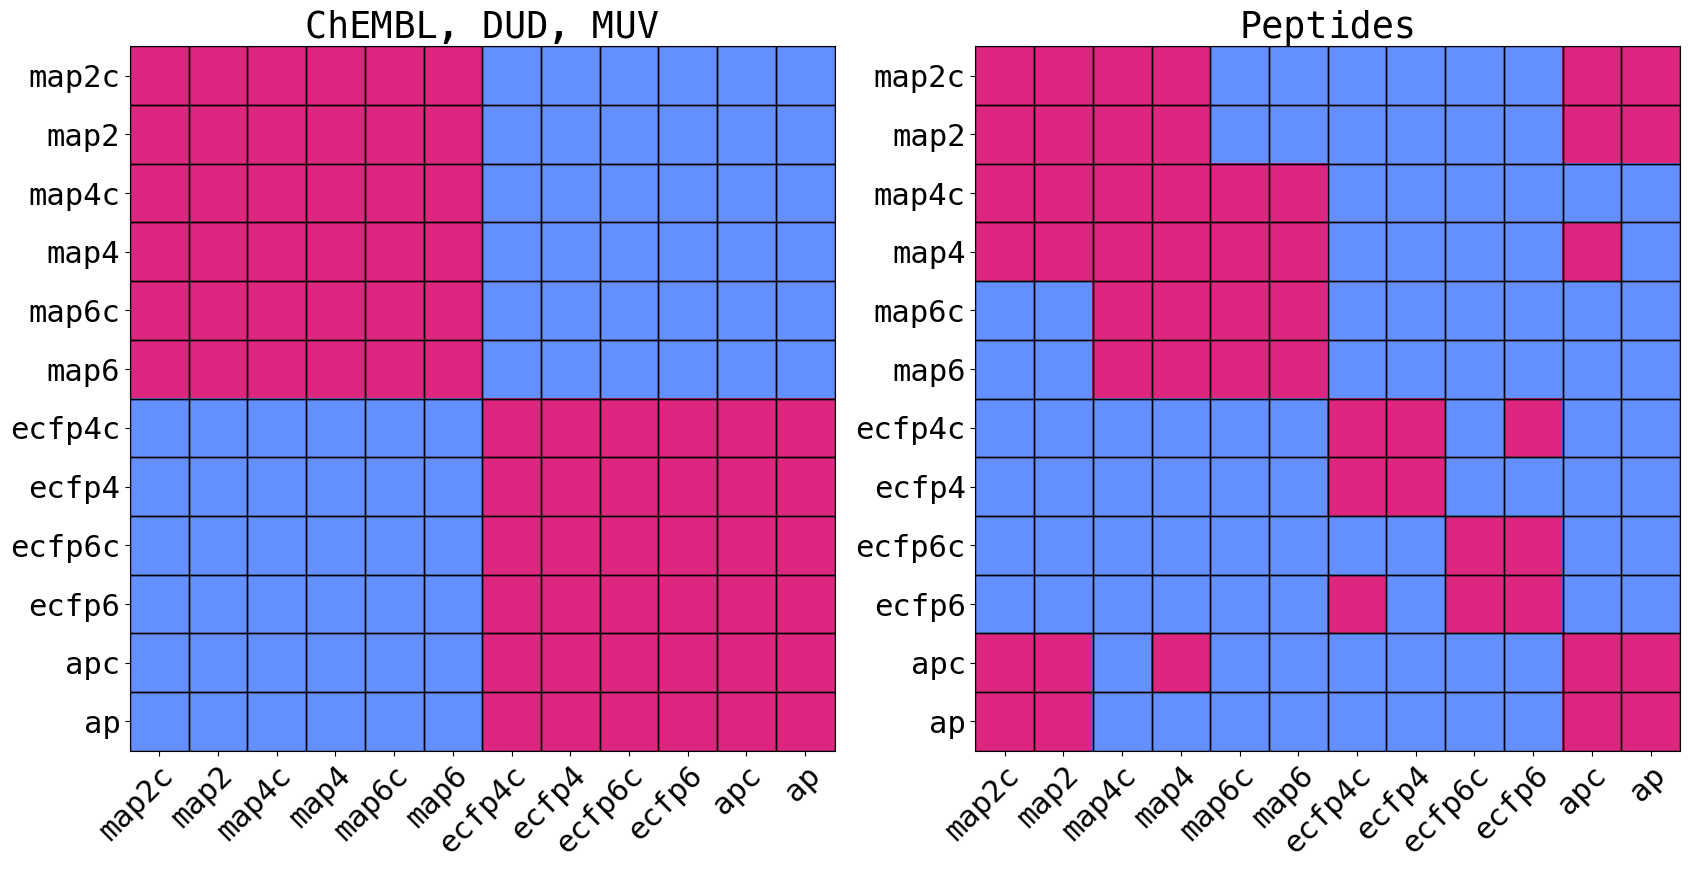

In [121]:
generate_friedman_heatmaps(ranked_aucs, 'auc')
generate_friedman_heatmaps(ranked_ef1, 'ef1')
generate_friedman_heatmaps(ranked_ef5, 'ef5')
generate_friedman_heatmaps(ranked_bedroc20, 'bedroc20')
generate_friedman_heatmaps(ranked_bedroc100, 'bedroc100')
generate_friedman_heatmaps(ranked_rie20, 'rie20')
generate_friedman_heatmaps(ranked_rie100, 'rie100')

#### Fingerprint Pearson Correlations

In [131]:
def pairwise_pearson_correlation(array2d):
    pearsons = np.zeros((len(array2d[0]), len(array2d[0])))
    p_values = np.zeros((len(array2d[0]), len(array2d[0])))
    for i in range(len(array2d[0])):
        for j in range(len(array2d[0])):
            pearsons[i][j] = pearsonr(array2d[:, i], array2d[:, j])[0]
            p_values[i][j] = pearsonr(array2d[:, i], array2d[:, j])[1]
    return pearsons

def generate_pearson_heatmaps(df, metric='auc'):

    # Separate the data into small molecules and peptides
    data = df.values
    data_small, data_peptides = data[:-60], data[-60:]

    # Calculate the pairwise Pearson correlation coefficient
    pearson_small, pearson_peptides = pairwise_pearson_correlation(data_small), pairwise_pearson_correlation(data_peptides)

    # Define IBM colorblind colormap
    ibm_colorblind = LinearSegmentedColormap.from_list('ibm_colorblind', ['#648FFF', '#DC267F'], N=256)

    # Plot heatmaps 
    fig, ax = plt.subplots(1, 2, figsize=(20, 10))

    im = ax[0].imshow(pearson_small, cmap=ibm_colorblind)
    ax[0].set_title('ChEMBL, DUD, MUV')
    ax[0].set_xticks(np.arange(len(df.columns)))
    ax[0].set_yticks(np.arange(len(df.columns)))
    ax[0].set_xticklabels(df.columns)
    ax[0].set_yticklabels(df.columns)

    im = ax[1].imshow(pearson_peptides, cmap=ibm_colorblind)
    ax[1].set_title('Peptides')
    ax[1].set_xticks(np.arange(len(df.columns)))
    ax[1].set_yticks(np.arange(len(df.columns)))
    ax[1].set_xticklabels(df.columns)
    ax[1].set_yticklabels(df.columns)

    plt.setp(ax[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.setp(ax[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Show values 
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            text = ax[0].text(j, i, f'{pearson_small[i, j]:.2f}', ha='center', va='center', color='black', fontsize=12)
            text = ax[1].text(j, i, f'{pearson_peptides[i, j]:.2f}', ha='center', va='center', color='black', fontsize=12)

    # Add frame to heatmap cells
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', lw=1)
            ax[0].add_patch(rect)
            rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor='black', lw=1)
            ax[1].add_patch(rect)

    # Save figure 
    savename = f'plots/pearson_heatmaps_{metric}.png'
    plt.savefig(savename, dpi=1200, bbox_inches='tight')

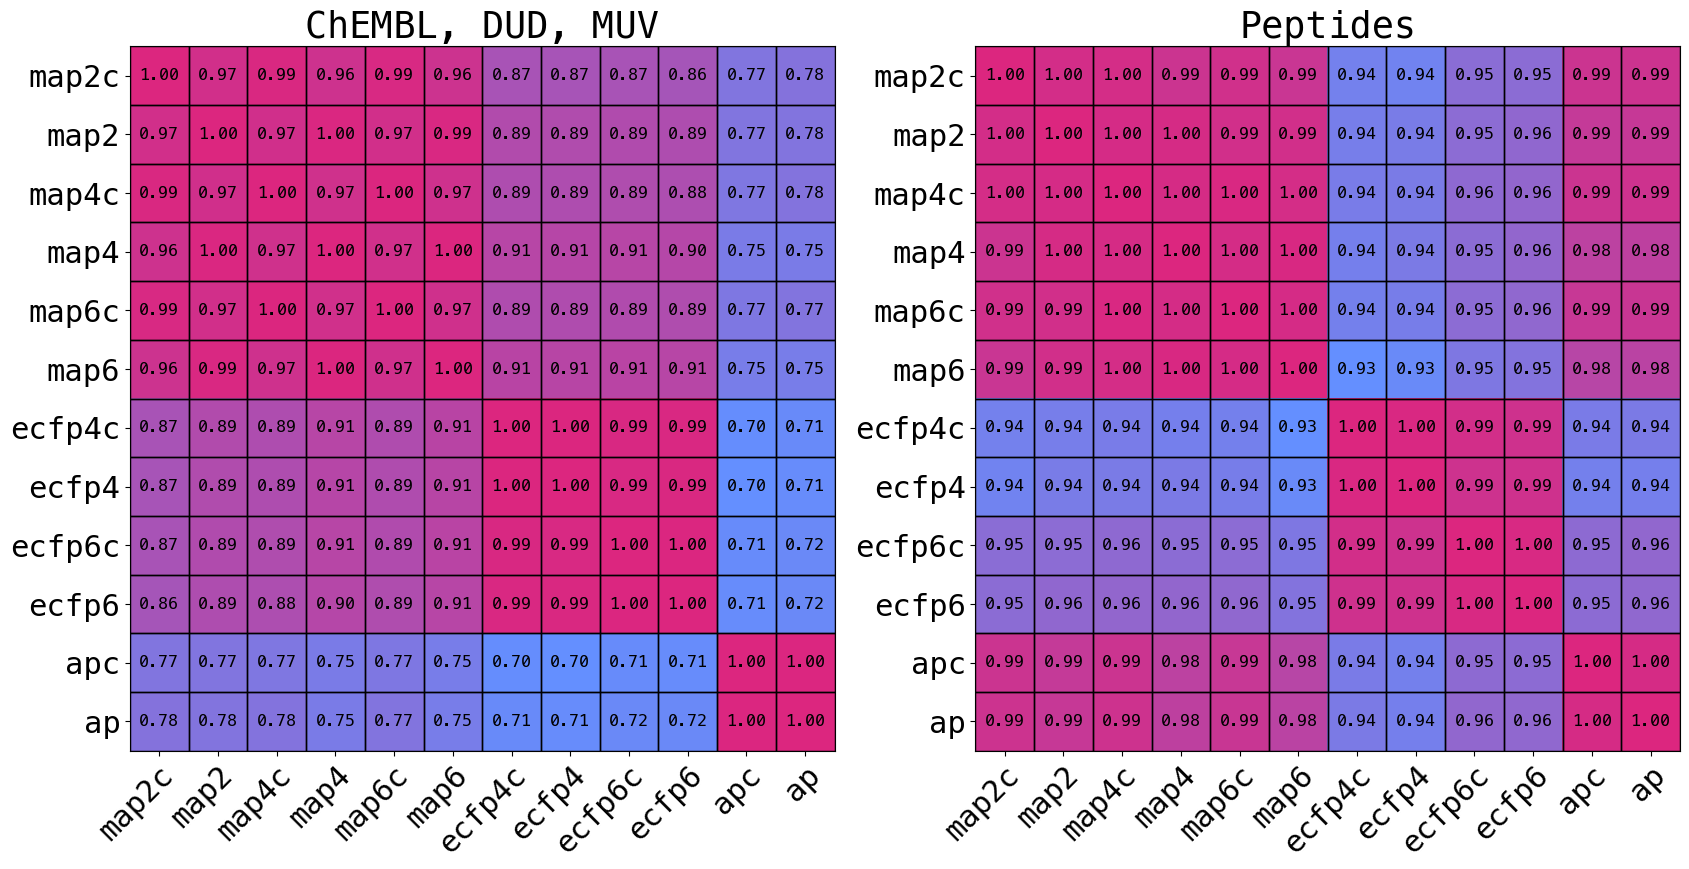

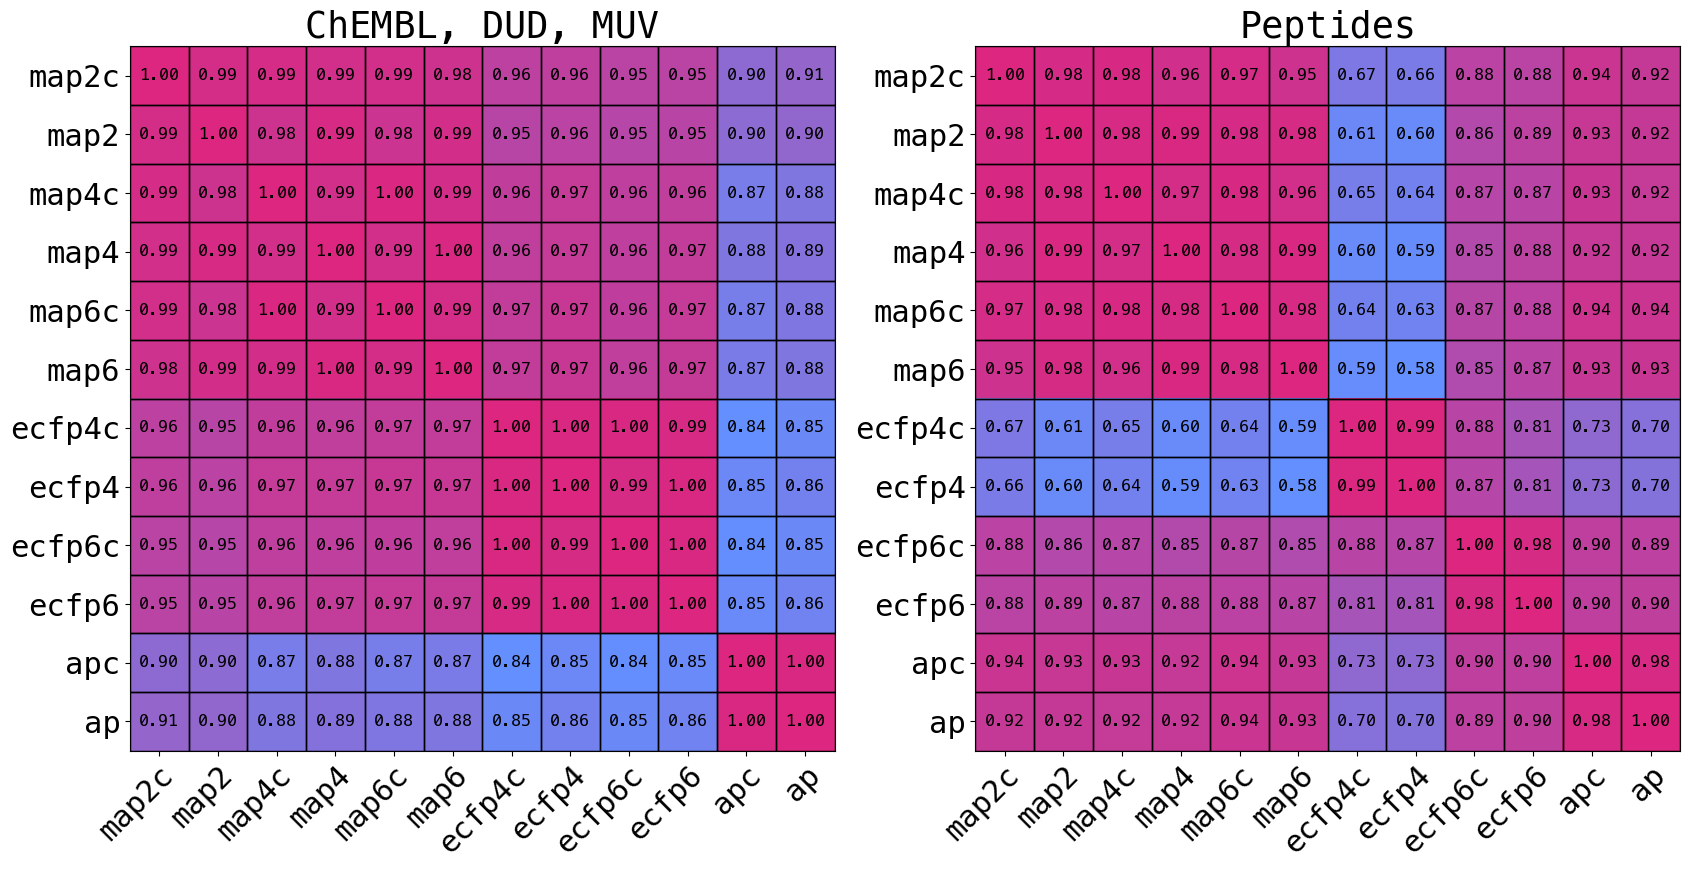

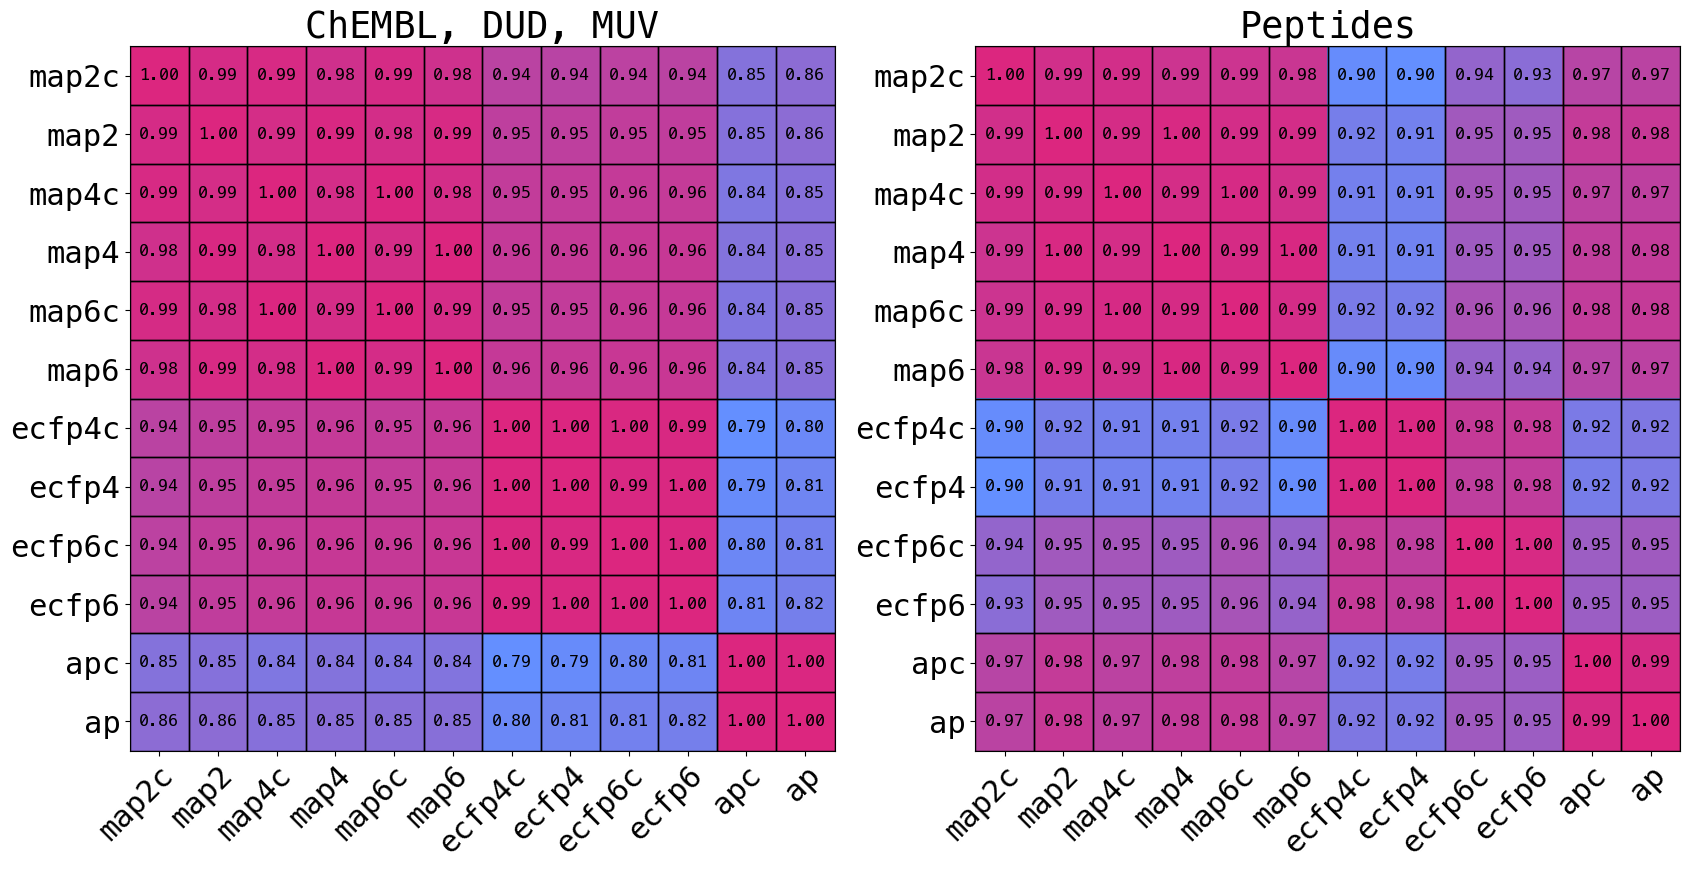

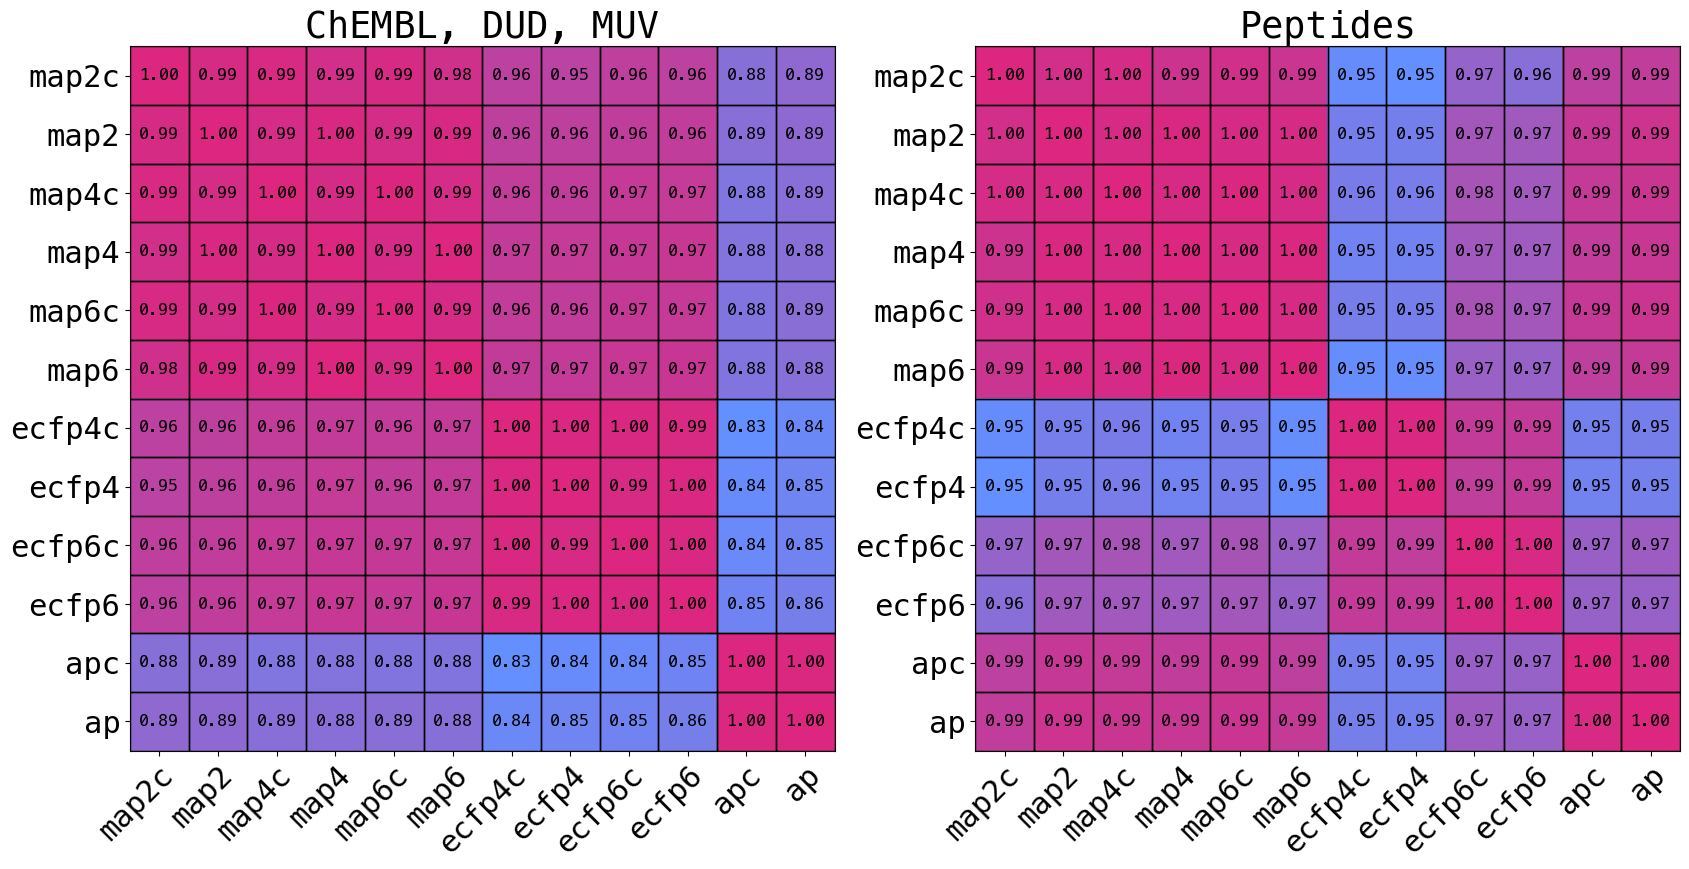

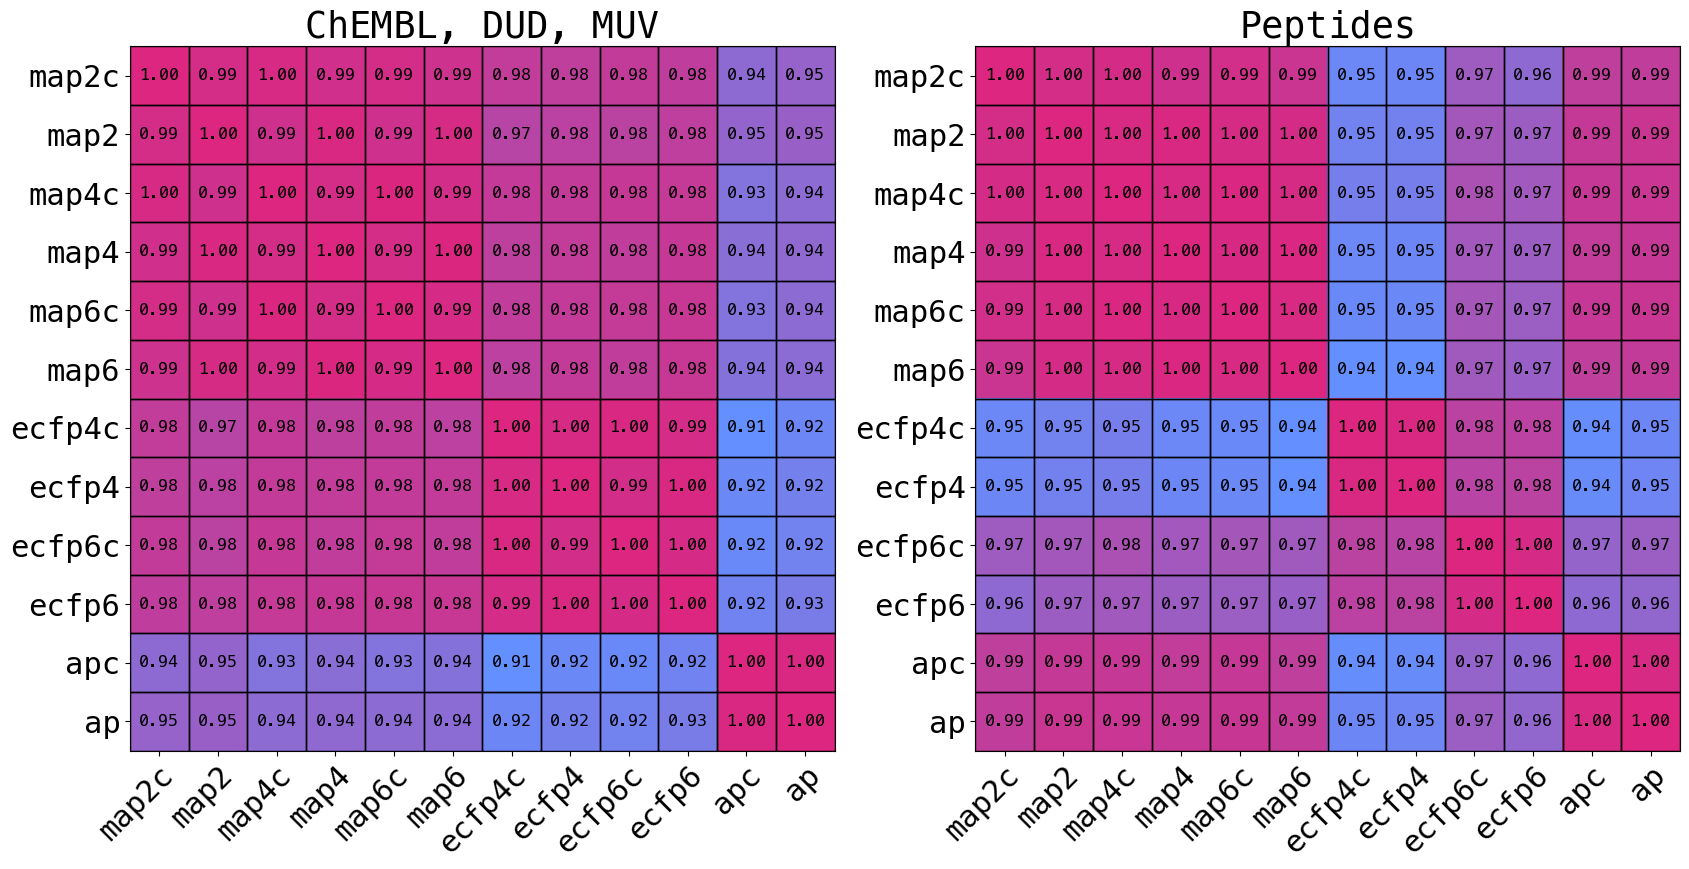

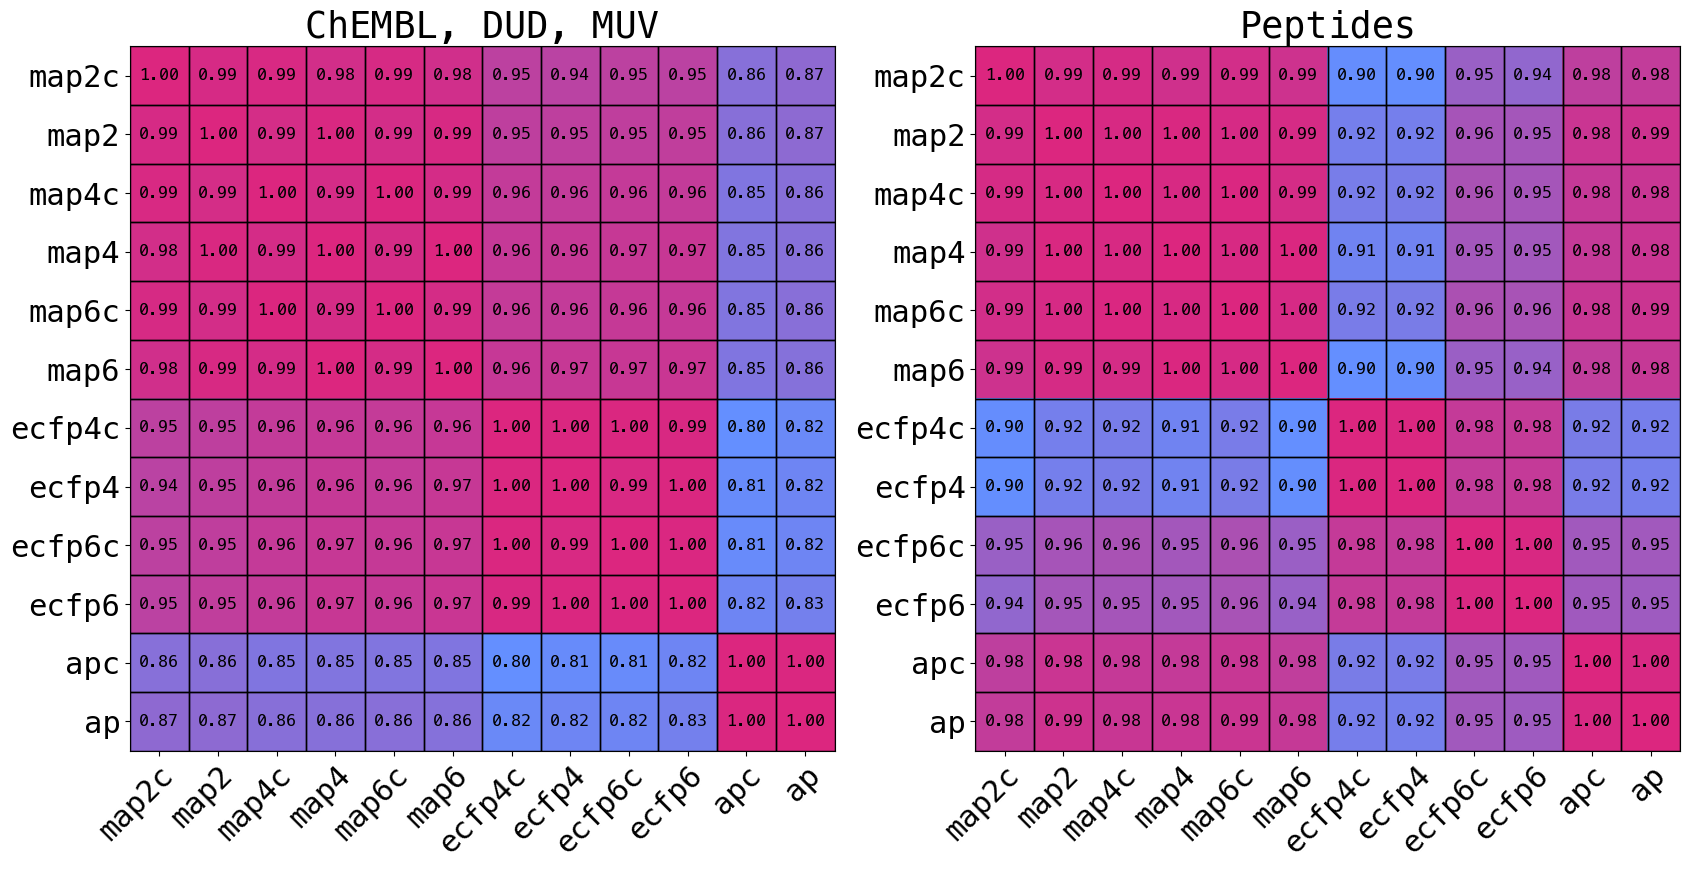

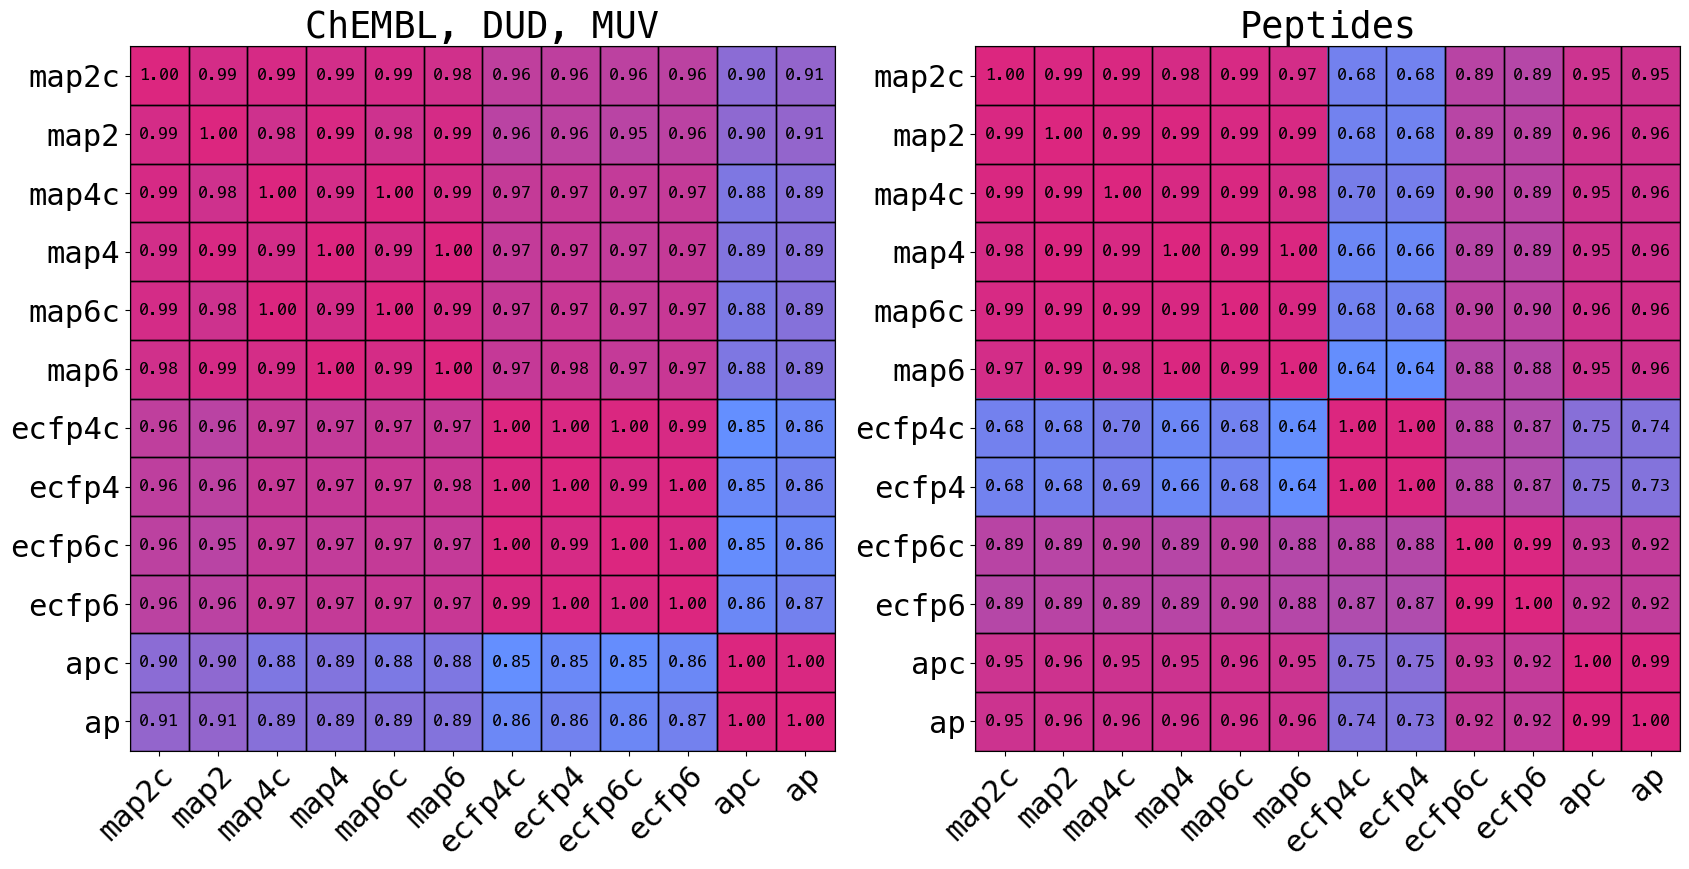

In [134]:
generate_pearson_heatmaps(mean_aucs, 'auc')
generate_pearson_heatmaps(mean_ef1, 'ef1')
generate_pearson_heatmaps(mean_ef5, 'ef5')
generate_pearson_heatmaps(mean_bedroc20, 'bedroc20')
generate_pearson_heatmaps(mean_bedroc100, 'bedroc100')
generate_pearson_heatmaps(mean_rie20, 'rie20')
generate_pearson_heatmaps(mean_rie100, 'rie100')